# Food Data Analysis
### This file cleans and analyses the filtered USDA food dataset and examine the nutrients and categories of food. 
### NOTE: This file can only be run after running the 'WORKING_APP.py' file.

In [ ]:
#Importing essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Libraries for machine learning
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df_food = pd.read_csv("food.csv")
df_food.head()

,fdc_id,data_type,description,food_category_id,publication_date
0,319874,sample_food,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
1,319875,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
2,319876,market_acquisition,"HUMMUS, SABRA CLASSIC",16.0,2019-04-01
3,319877,sub_sample_food,Hummus,16.0,2019-04-01
4,319878,sub_sample_food,Hummus,16.0,2019-04-01


In [3]:
food_matrix_5d = pd.read_csv("food_matrix_5d.csv")
food_matrix_5d.head()

,food_description,food_category_id,"Fiber, total dietary","Fatty acids, total polyunsaturated","Magnesium, Mg",Vitamin_D_Total_UG,"Zinc, Zn",id,description
0,"Alaska Pollock, raw",15.0,0.000,0.4577,22.820,0.000000,0.431300,15,Finfish and Shellfish Products
1,"Almond butter, creamy",12.0,9.718,12.6100,267.800,0.000000,3.178000,12,Nut and Seed Products
2,"Almond milk, unsweetened",14.0,0.000,0.2763,7.273,1.147117,0.140070,14,Beverages
3,"Anchovies, canned in olive oil",15.0,0.000,0.0000,227.600,0.000000,2.539000,15,Finfish and Shellfish Products
4,"Apple juice, with added vitamin C",9.0,0.000,0.0000,4.861,0.000000,0.002125,9,Fruits and Fruit Juices


In [ ]:
#Target nutrients matching to nutrients names in the USDA Nutrition/Food datasets

#Loading the nutrition datasets
df_food_nutrient = pd.read_csv('food_nutrient.csv')
df_nutrient = pd.read_csv('nutrient.csv')

#Seperating the target nutrients using the USDA nutrient ids
usda_ids = [291, 646, 304]
df_selected_nutrients = df_nutrient[df_nutrient['nutrient_nbr'].isin(usda_ids)]

#Relational Merge Pipeline
#Linking the filtered nutrients to the bridge table
merge_part1 = pd.merge(df_food_nutrient, df_selected_nutrients, left_on='nutrient_id', right_on='id', how='inner')

#Linking the result to food name table
df_joined = pd.merge(merge_part1, df_food, on='fdc_id', how='inner')

#Converting the table from a vertical format to horizontal format
#Each row represents one unique food
food_matrix = df_joined.pivot_table(
    index='description',
    columns='name',
    values='amount',
    aggfunc='mean'
).fillna(0)

#Renaming fiber to fibre 
food_matrix.rename(columns={'Fiber, total dietary': 'Fibre, total dietary'}, inplace=True)

#Vector for the target nutrients 
target_nutrients = [
    'Fibre, total dietary', 
    'Fatty acids, total polyunsaturated',
    'Magnesium, Mg' 
]

filtered_food_matrix = food_matrix[target_nutrients]

#Cosine similarity reccomender function
def recommend_food(patient_vector, food_db, top_n=10):

    #Converting patient vectors to a 2D row array
    vector_array_2d = np.array(patient_vector).reshape(1, -1)

    #Calculating the Cosine Similarity across all matrix rows simultaneously 
    similar_scores = cosine_similarity(vector_array_2d, food_db)[0]

    #Compiling the results into a readable output table
    results_df = food_db.copy()
    results_df['Match Score (%)'] = np.round(similar_scores * 100, 2)

    #Sorting from highest geometric match to lowest
    return results_df.sort_values(by='Match Score (%)', ascending=False).head(top_n)

#Testing the food matrix works with an initial cosine similarity recommender system
patient_vector_test = [35.0, 20.0, 400.0]

top_reccomendations = recommend_food(patient_vector_test, filtered_food_matrix, top_n=5)
print("Top matching food reccomended:")
print(top_reccomendations)


Top matching food reccomended:
name                                                Fibre, total dietary  \
description                                                                
Edamame, frozen, prepared                                         6.2326   
Restaurant, Latino, pupusas con frijoles (pupus...                5.8000   
Bread, white, commercially prepared                               2.3000   
Sauce, pasta, spaghetti/marinara, ready-to-serve                  1.8000   
Restaurant, Latino, tamale, pork                                  2.4000   

name                                                Fatty acids, total polyunsaturated  \
description                                                                              
Edamame, frozen, prepared                                                       4.0726   
Restaurant, Latino, pupusas con frijoles (pupus...                              2.8800   
Bread, white, commercially prepared                                         

C:\Users\Lily Jayne Baxendale\AppData\Local\Temp\ipykernel_21020\459462572.py:4: DtypeWarning: Columns (0: footnote) have mixed types. Specify dtype option on import or set low_memory=False.
  df_food_nutrient = pd.read_csv('food_nutrient.csv')


# Analysing the food_matrix_5d dataset

### Calculating the percentage and counts of food categories

In [5]:
#Loading the nutrition datasets
food_data = pd.read_csv('food.csv')
df_food_nutrient = pd.read_csv('food_nutrient.csv', low_memory=False)
df_nutrient = pd.read_csv('nutrient.csv')
df_category = pd.read_csv('food_category.csv')

#Seperating the target nutrients using the USDA nutrient ids
target_usda_ids = [291, 646, 304, 309, 325, 326]
df_selected_nutrients_2 = df_nutrient[df_nutrient['nutrient_nbr'].isin(target_usda_ids)]

#Fixing the filtering 
#Filtering for only master food records and filtering out lab tests and sub samples
valid_data_types=['foundation_food', 'sr_legacy_food']
food_data = food_data[food_data['data_type'].isin(valid_data_types)]

#Relational Merge Pipeline
#Linking the filtered nutrients to the bridge table
merge_part_1 = pd.merge(df_food_nutrient, df_selected_nutrients_2, left_on='nutrient_id', right_on='id', how='inner')

#Linking the result to food name table
df_joined_3 = pd.merge(merge_part_1, food_data, on='fdc_id', how='inner')

#Using the short name to merge duplicate foods
food_matrix_2 = df_joined_3.pivot_table(
    index=['description', 'food_category_id'],
    columns='name',
    values='amount',
    aggfunc='mean'
).fillna(0).reset_index()

#Renaming fiber to fibre 
food_matrix_2.rename(columns={'Fiber, total dietary': 'Fibre, total dietary'}, inplace=True)

#Calculating the total vitamin D
vit_d2 = food_matrix_2.get('Vitamin D2 (ergocalciferol)', 0)
vit_d3 = food_matrix_2.get('Vitamin D3 (cholecalciferol)', 0)
food_matrix_2['Vitamin_D_Total_UG'] = vit_d2 + vit_d3

#Vector for the target nutrients 
nutrients_5d_order = [
    'description',
    'food_category_id',
    'Fibre, total dietary', 
    'Fatty acids, total polyunsaturated',
    'Magnesium, Mg',
    'Vitamin_D_Total_UG',
    'Zinc, Zn'
]

food_matrix_5d = food_matrix_2[nutrients_5d_order].copy()
food_matrix_5d.rename(columns={'description': 'food_description'}, inplace=True)

#Merging with food_category.csv to get the text name of the categories
food_matrix_5d = pd.merge(
    food_matrix_5d,
    df_category[['id', 'description']],
    left_on='food_category_id',
    right_on='id',
    how='left'
)

#Renaming the merged category description column and dropping 'id' as its now redundant
food_matrix_5d.rename(columns={'description': 'category_name'}, inplace=True)
food_matrix_5d.drop(columns=['id'], inplace=True)

#Calculating the counts and percentages
category_counts = food_matrix_5d['category_name'].value_counts()
category_percentages = food_matrix_5d['category_name'].value_counts()
category_percentages = food_matrix_5d['category_name'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Total Items': category_counts,
    'Percentage (%)': category_percentages.round(2)
})

print("Category Distribution:")
print(summary_df)

food_matrix_5d.to_csv("food_matrix_5d_categorised.csv", index=False)

Category Distribution:
                                   Total Items  Percentage (%)
category_name                                                 
Vegetables and Vegetable Products           90           22.56
Fruits and Fruit Juices                     58           14.54
Legumes and Legume Products                 43           10.78
Cereal Grains and Pasta                     43           10.78
Dairy and Egg Products                      41           10.28
Finfish and Shellfish Products              24            6.02
Nut and Seed Products                       19            4.76
Beef Products                               15            3.76
Sausages and Luncheon Meats                 14            3.51
Fats and Oils                               12            3.01
Poultry Products                            11            2.76
Baked Products                               8            2.01
Pork Products                                7            1.75
Restaurant Foods                

### Calculating the percentage of foods containing the target nutrients 

In [6]:
#Loading the finalised food database
df = pd.read_csv("food_matrix_5d_categorised.csv")

#Vector for the target nutrients 
nutrients_5d_order = [
    'Fibre, total dietary', 
    'Fatty acids, total polyunsaturated',
    'Magnesium, Mg',
    'Vitamin_D_Total_UG',
    'Zinc, Zn'
]

#Initialise an empty list for the resultss
results = []
total_foods = len(df)

#Looping through each nutrient to calculate the counts & percentages
for nutrient in nutrients_5d_order:
    #Counting foods where the nutrient amount is greater than 0
    contains_count = (df[nutrient] > 0).sum()
    not_contain_count = total_foods - contains_count

    #Calculating percentages
    contains_pct = (contains_count / total_foods) * 100
    not_contain_pct = (not_contain_count / total_foods) * 100

    #Appending results
    results.append({
        'Nutrient': nutrient,
        'Contains (Count)': contains_count,
        'Contains (%)': round(contains_pct, 2),
        'Does Not Contain (Count)': not_contain_count,
        'Does Not Contain (%)': round(not_contain_pct, 2)
    })

    #Converting the results
    nutrient_summary_df = pd.DataFrame(results)

    #Printing the results table
    print(f"Total Foods in Dataset: {total_foods}\n")
    print(nutrient_summary_df.to_string(index=False))

Total Foods in Dataset: 399

            Nutrient  Contains (Count)  Contains (%)  Does Not Contain (Count)  Does Not Contain (%)
Fibre, total dietary               198         49.62                       201                 50.38
Total Foods in Dataset: 399

                          Nutrient  Contains (Count)  Contains (%)  Does Not Contain (Count)  Does Not Contain (%)
              Fibre, total dietary               198         49.62                       201                 50.38
Fatty acids, total polyunsaturated               112         28.07                       287                 71.93
Total Foods in Dataset: 399

                          Nutrient  Contains (Count)  Contains (%)  Does Not Contain (Count)  Does Not Contain (%)
              Fibre, total dietary               198         49.62                       201                 50.38
Fatty acids, total polyunsaturated               112         28.07                       287                 71.93
                     

Database Category Distribution

C:\Users\Lily Jayne Baxendale\AppData\Local\Temp\ipykernel_21020\3342082840.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=percentages, y=categories, palette='mako')


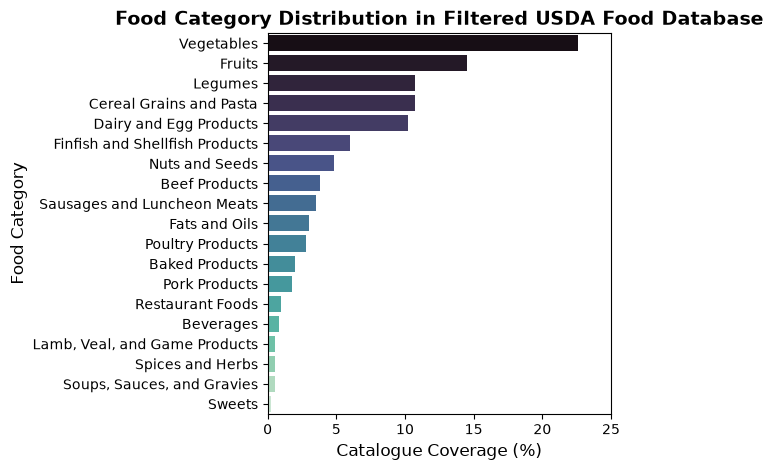

In [ ]:
#Database Category Distribution via Bar Chart
#Defining the categories
categories = [
    'Vegetables', 'Fruits', 'Legumes', 'Cereal Grains and Pasta',
    'Dairy and Egg Products', 'Finfish and Shellfish Products',
    'Nuts and Seeds', 'Beef Products', 'Sausages and Luncheon Meats',
    'Fats and Oils', 'Poultry Products', 'Baked Products', 'Pork Products',
    'Restaurant Foods', 'Beverages', 'Lamb, Veal, and Game Products',
    'Spices and Herbs', 'Soups, Sauces, and Gravies', 'Sweets'
]

#Percentages of the food categories after filtering
percentages = [22.6, 14.5, 10.7, 10.7, 10.2, 6.0, 4.8, 3.8, 3.5, 3.0, 2.8,
               2.0, 1.8, 1.0, 0.8, 0.5, 0.5, 0.5, 0.25]

#Configuring the bar chart x and y axises
ax = sns.barplot(x=percentages, y=categories, palette='mako')

#Adding data labels to the bar chart plot and configuring the size
plt.title('Food Category Distribution in Filtered USDA Food Database', fontsize=14, fontweight='bold')
plt.ylabel('Food Category', fontsize=12)
plt.xlabel('Catalogue Coverage (%)', fontsize=12)
plt.xlim(0, 25)
plt.tight_layout()
plt.show()

#As shown in the diagram, the filtered dataset contains a wide variety of food categories, with fruit and vegetables being the majority categories.